In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("sales_data.csv")

df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(100, 7)

Column Names:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 8.3 KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [5]:
df.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

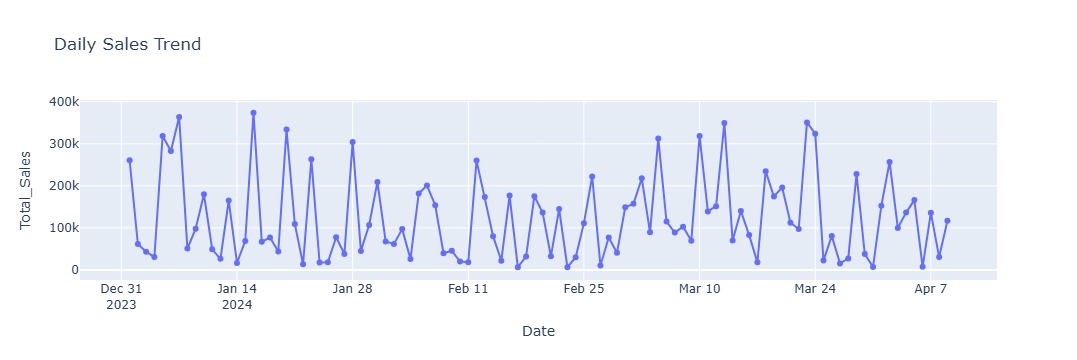

In [28]:
daily_sales = df.groupby("Date")["Total_Sales"].sum().reset_index()

fig = px.line(
    daily_sales,
    x="Date",
    y="Total_Sales",
    markers=True,
    title="Daily Sales Trend"
)

fig.show()

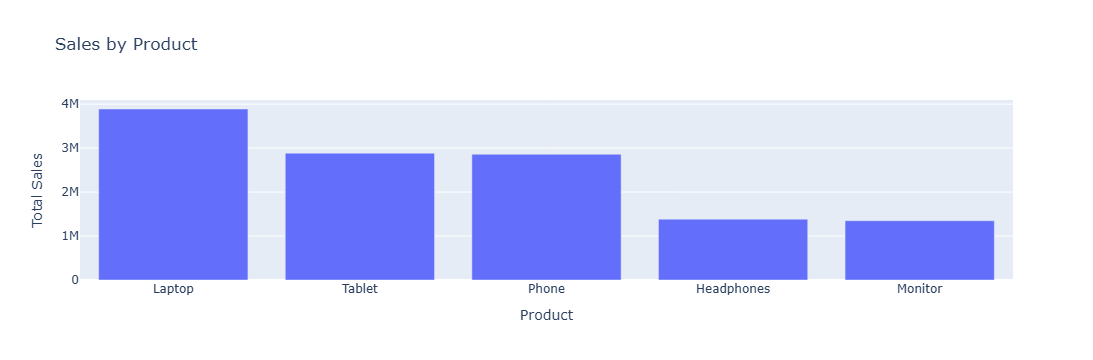

In [12]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

fig = px.bar(
    product_sales,
    x=product_sales.index,
    y=product_sales.values,
    title="Sales by Product",
    labels={
        "x": "Product",
        "y": "Total Sales"
    }
)

fig.show()

fig.write_image("visualizations/product_performance.png")

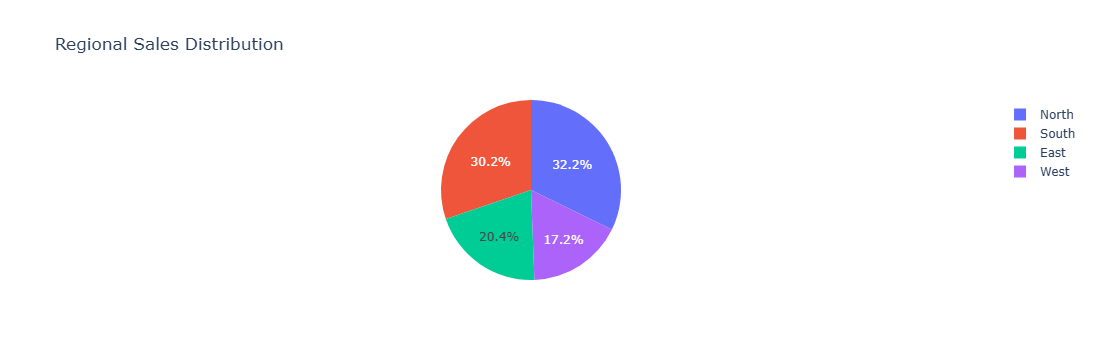

In [13]:
region_sales = df.groupby("Region")["Total_Sales"].sum().reset_index()

fig = px.pie(
    region_sales,
    names="Region",
    values="Total_Sales",
    title="Regional Sales Distribution"
)

fig.show()

fig.write_image("visualizations/regional_sales.png")

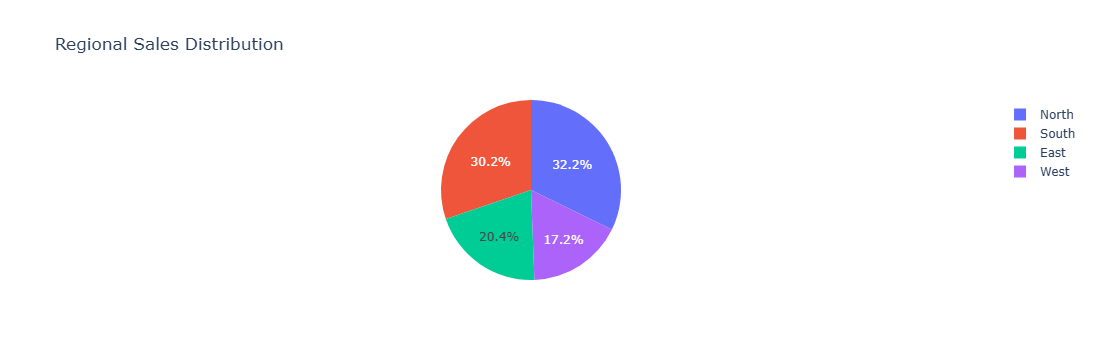

In [14]:
ffig = px.scatter(
    df,
    x="Quantity",
    y="Total_Sales",
    color="Product",
    size="Price",
    hover_data=["Customer_ID", "Region"],
    title="Quantity vs Total Sales"
)

fig.show()

fig.write_image("visualizations/quantity_vs_sales.png")

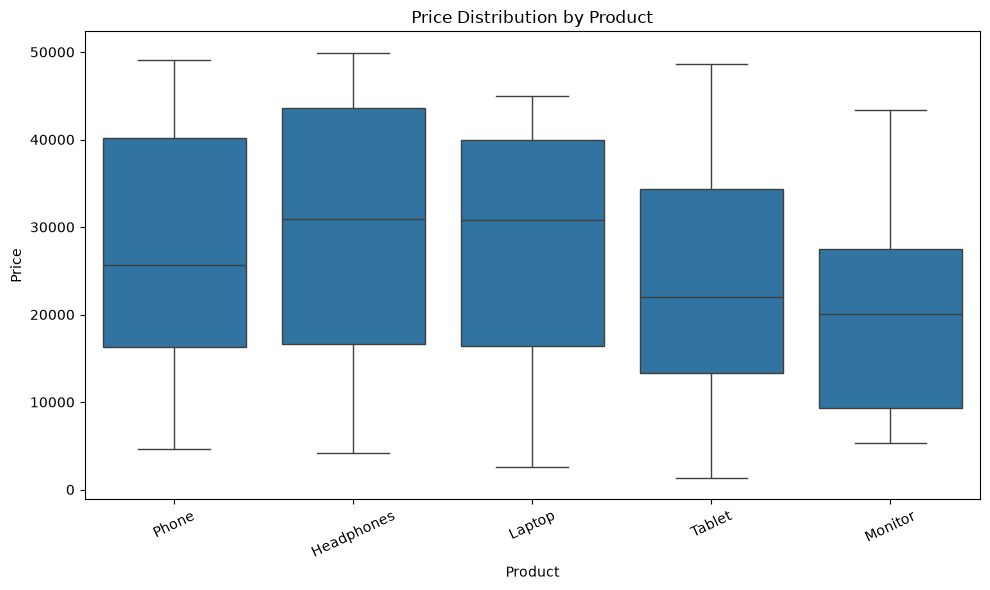

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="Product",
    y="Price",
    data=df
)

plt.title("Price Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Price")
plt.xticks(rotation=25)

plt.tight_layout()

plt.savefig("visualizations/price_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

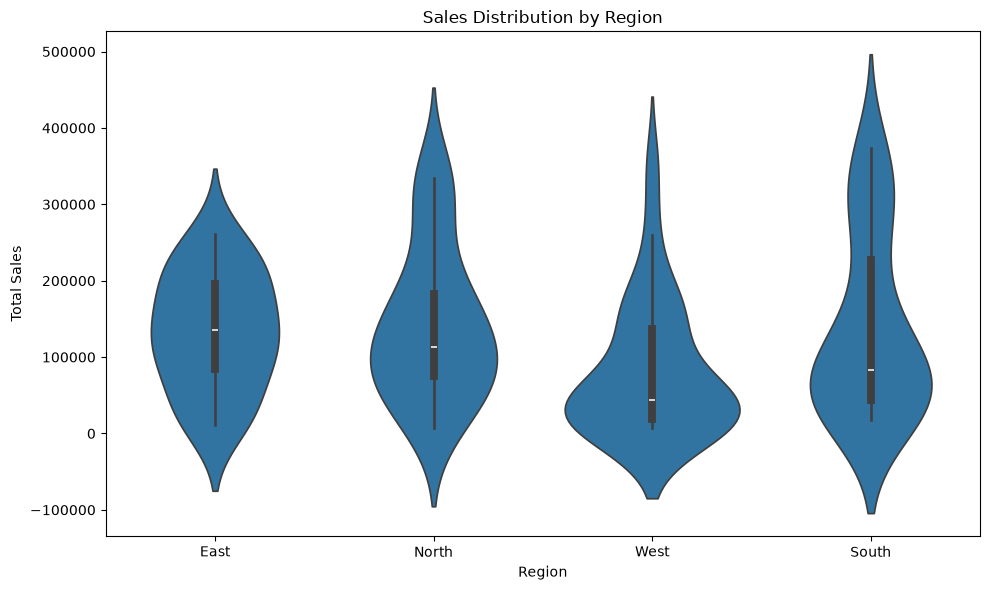

In [16]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    x="Region",
    y="Total_Sales",
    data=df
)

plt.title("Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("visualizations/sales_violin.png", dpi=300, bbox_inches="tight")

plt.show()

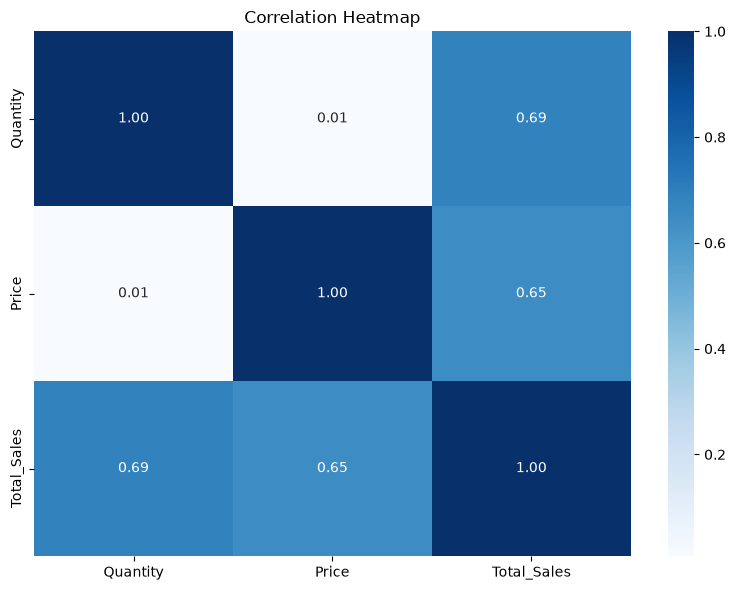

In [17]:
correlation = df[
    ["Quantity", "Price", "Total_Sales"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
customer_spending = (
    df.groupby("Customer_ID")["Total_Sales"]
    .sum()
)

customer_spending.head()

Customer_ID
CUST001    261100
CUST002     61624
CUST003     43492
CUST004     30895
CUST005    318680
Name: Total_Sales, dtype: int64

In [15]:
q1 = customer_spending.quantile(0.33)
q2 = customer_spending.quantile(0.66)

print("Low Value threshold:", q1)
print("Medium Value threshold:", q2)

Low Value threshold: 58063.30000000002
Medium Value threshold: 150054.08000000002


In [16]:
def segment_customer(value):
    if value <= q1:
        return "Low Value"
    elif value <= q2:
        return "Medium Value"
    else:
        return "High Value"

customer_segment = customer_spending.apply(segment_customer)

customer_segment.value_counts()

Total_Sales
High Value      34
Medium Value    33
Low Value       33
Name: count, dtype: int64

In [17]:
df["Customer_Segment"] = df["Customer_ID"].map(customer_segment)

df[["Customer_ID", "Customer_Segment"]].drop_duplicates().head()

,Customer_ID,Customer_Segment
0,CUST001,High Value
1,CUST002,Medium Value
2,CUST003,Low Value
3,CUST004,Low Value
4,CUST005,High Value


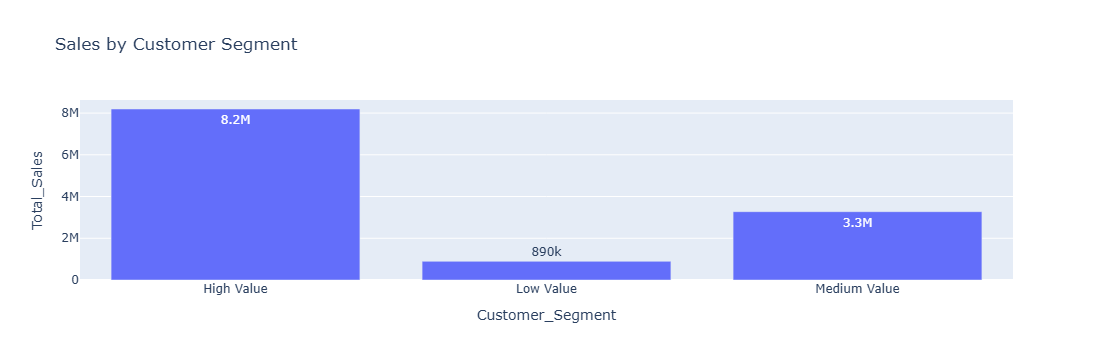

In [18]:
segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    segment_sales,
    x="Customer_Segment",
    y="Total_Sales",
    title="Sales by Customer Segment",
    text_auto=".2s"
)

fig.show()

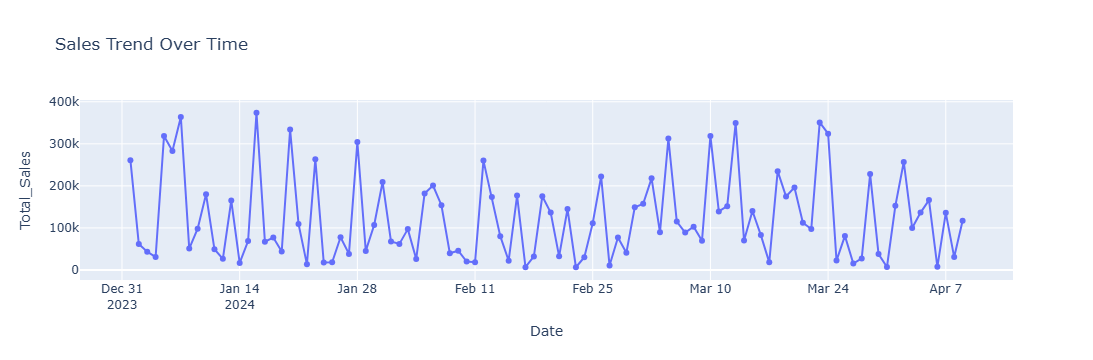

In [19]:


df["Date"] = pd.to_datetime(df["Date"])

daily_sales = (
    df.groupby("Date")["Total_Sales"]
    .sum()
    .reset_index()
)

fig = px.line(
    daily_sales,
    x="Date",
    y="Total_Sales",
    title="Sales Trend Over Time",
    markers=True
)

fig.show()

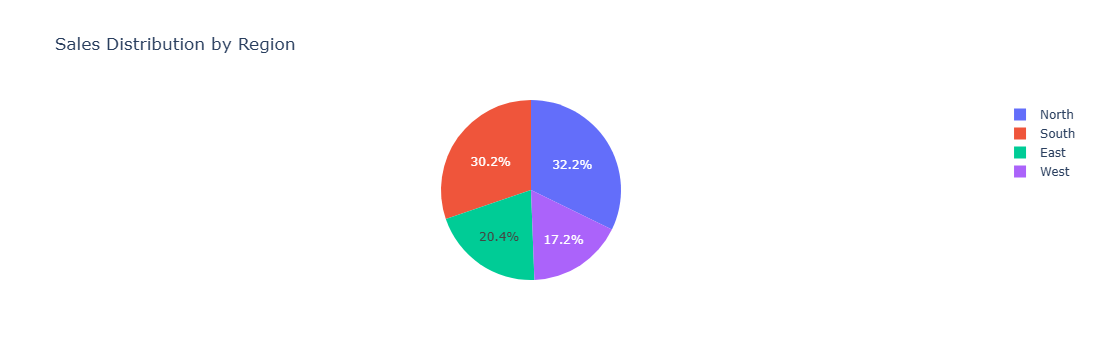

In [20]:
# STEP 22 — Sales by Region

region_sales = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .reset_index()
)

fig = px.pie(
    region_sales,
    names="Region",
    values="Total_Sales",
    title="Sales Distribution by Region"
)

fig.show()

In [21]:
!pip install kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   ---------------------------------------- 5/5 [kaleido]



In [24]:
%pip install -U "kaleido>=1"


Note: you may need to restart the kernel to use updated packages.


In [26]:
%pip install -U "kaleido>=1"


Note: you may need to restart the kernel to use updated packages.


In [29]:
import kaleido
print("Kaleido installed successfully!")

Kaleido installed successfully!


In [32]:
import sys
!{sys.executable} -m pip install -U "kaleido>=1"

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import importlib.metadata

print(importlib.metadata.version("kaleido"))

1.4.0


In [6]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("sales_data.csv")

print(df.head())
print(df.shape)

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
(100, 7)


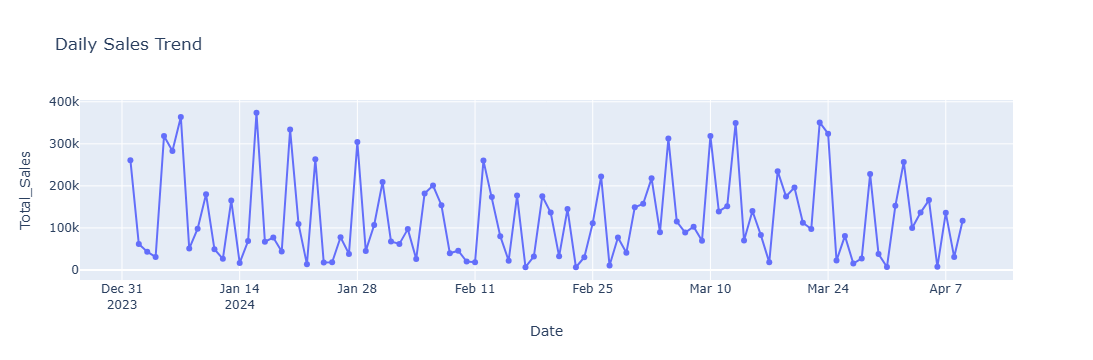

Sales trend image saved successfully!


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

daily_sales = df.groupby("Date")["Total_Sales"].sum().reset_index()

fig = px.line(
    daily_sales,
    x="Date",
    y="Total_Sales",
    markers=True,
    title="Daily Sales Trend"
)

fig.show()

fig.write_image("visualizations/sales_trend.png")

print("Sales trend image saved successfully!")

In [9]:
plt.savefig("visualizations/price_boxplot.png")

<Figure size 640x480 with 0 Axes>

In [19]:
import os

print(os.listdir("visualizations"))

['correlation_heatmap.png', 'price_boxplot.png', 'product_performance.png', 'quantity_vs_sales.png', 'regional_sales.png', 'sales_trend.png', 'sales_violin.png']


In [21]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("sales_data.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0 2024-01-01       Phone         7  37300     CUST001   East       261100
1 2024-01-02  Headphones         4  15406     CUST002  North        61624
2 2024-01-03       Phone         2  21746     CUST003   West        43492
3 2024-01-04  Headphones         1  30895     CUST004   East        30895
4 2024-01-05      Laptop         8  39835     CUST005  North       318680


In [22]:
# Product filter
product_options = ["All"] + sorted(df["Product"].unique().tolist())

# Region filter
region_options = ["All"] + sorted(df["Region"].unique().tolist())

print("Products:", product_options)
print("Regions:", region_options)

Products: ['All', 'Headphones', 'Laptop', 'Monitor', 'Phone', 'Tablet']
Regions: ['All', 'East', 'North', 'South', 'West']


In [23]:
import plotly.graph_objects as go

# Create dashboard function
def create_dashboard(product="All", region="All"):

    # Apply filters
    filtered_df = df.copy()

    if product != "All":
        filtered_df = filtered_df[filtered_df["Product"] == product]

    if region != "All":
        filtered_df = filtered_df[filtered_df["Region"] == region]

    # KPI calculations
    total_sales = filtered_df["Total_Sales"].sum()
    total_quantity = filtered_df["Quantity"].sum()
    total_transactions = len(filtered_df)
    average_sales = filtered_df["Total_Sales"].mean()

    # Sales trend
    daily_sales = (
        filtered_df.groupby("Date")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_trend = px.line(
        daily_sales,
        x="Date",
        y="Total_Sales",
        markers=True,
        title="Daily Sales Trend"
    )

    # Product performance
    product_sales = (
        filtered_df.groupby("Product")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_product = px.bar(
        product_sales,
        x="Product",
        y="Total_Sales",
        title="Sales by Product"
    )

    # Regional sales
    region_sales = (
        filtered_df.groupby("Region")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_region = px.pie(
        region_sales,
        names="Region",
        values="Total_Sales",
        title="Regional Sales Distribution"
    )

    # Display dashboard information
    print("=" * 50)
    print("INTERACTIVE SALES DASHBOARD")
    print("=" * 50)
    print(f"Product Filter: {product}")
    print(f"Region Filter: {region}")
    print("-" * 50)
    print(f"Total Sales: ₹{total_sales:,.2f}")
    print(f"Total Quantity: {total_quantity:,}")
    print(f"Total Transactions: {total_transactions:,}")
    print(f"Average Transaction Sales: ₹{average_sales:,.2f}")
    print("=" * 50)

    fig_trend.show()
    fig_product.show()
    fig_region.show()

INTERACTIVE SALES DASHBOARD
Product Filter: All
Region Filter: All
--------------------------------------------------
Total Sales: ₹12,365,048.00
Total Quantity: 478
Total Transactions: 100
Average Transaction Sales: ₹123,650.48


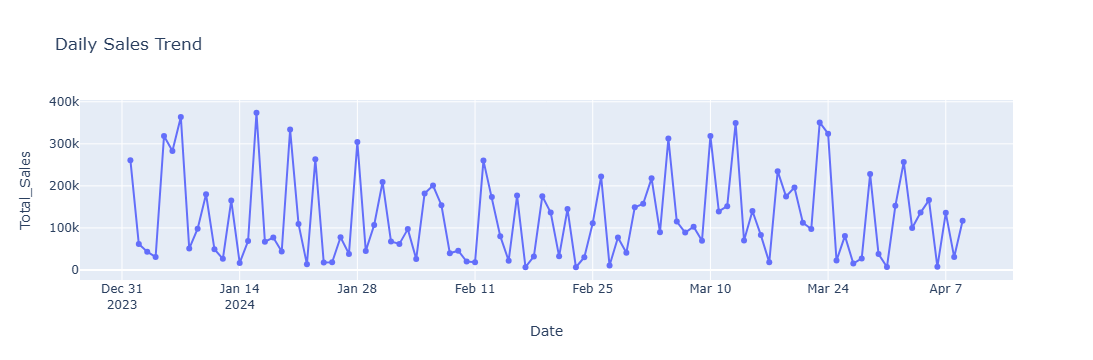

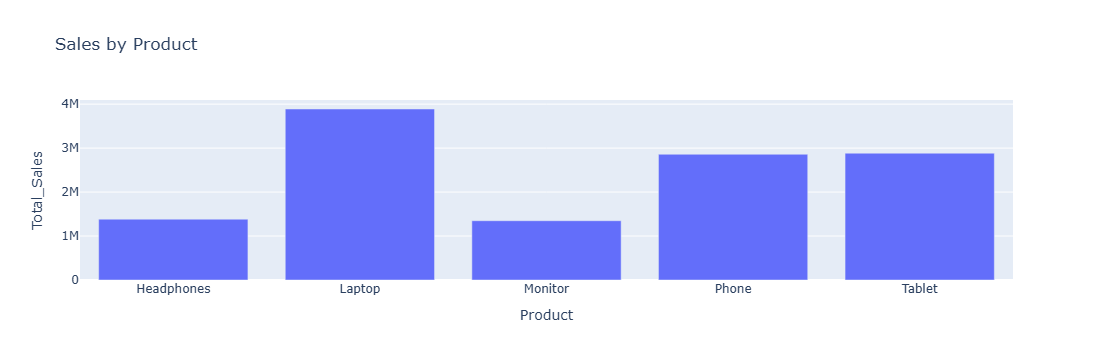

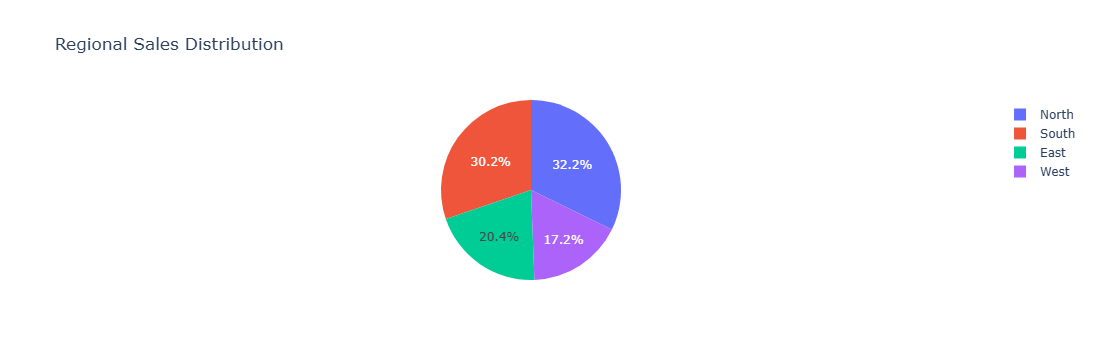

In [24]:
create_dashboard()

In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Product dropdown
product_dropdown = widgets.Dropdown(
    options=["All"] + sorted(df["Product"].unique().tolist()),
    value="All",
    description="Product:"
)

# Region dropdown
region_dropdown = widgets.Dropdown(
    options=["All"] + sorted(df["Region"].unique().tolist()),
    value="All",
    description="Region:"
)

# Output area
output = widgets.Output()

def update_dashboard(change=None):
    with output:
        clear_output(wait=True)

        product = product_dropdown.value
        region = region_dropdown.value

        create_dashboard(product, region)

# Connect dropdowns to dashboard
product_dropdown.observe(update_dashboard, names="value")
region_dropdown.observe(update_dashboard, names="value")

# Display dashboard
display(product_dropdown, region_dropdown, output)

# Show initial dashboard
update_dashboard()

Dropdown(description='Product:', options=('All', 'Headphones', 'Laptop', 'Monitor', 'Phone', 'Tablet'), value=…

Dropdown(description='Region:', options=('All', 'East', 'North', 'South', 'West'), value='All')

Output()

In [26]:
dashboard_code = '''
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("sales_data (2).csv")
df["Date"] = pd.to_datetime(df["Date"])

# Create dashboard function
def create_dashboard(product="All", region="All"):

    filtered_df = df.copy()

    if product != "All":
        filtered_df = filtered_df[filtered_df["Product"] == product]

    if region != "All":
        filtered_df = filtered_df[filtered_df["Region"] == region]

    # KPI calculations
    total_sales = filtered_df["Total_Sales"].sum()
    total_quantity = filtered_df["Quantity"].sum()
    total_transactions = len(filtered_df)
    average_sales = filtered_df["Total_Sales"].mean()

    print("=" * 50)
    print("INTERACTIVE SALES DASHBOARD")
    print("=" * 50)
    print(f"Product Filter: {product}")
    print(f"Region Filter: {region}")
    print("-" * 50)
    print(f"Total Sales: ₹{total_sales:,.2f}")
    print(f"Total Quantity: {total_quantity:,}")
    print(f"Total Transactions: {total_transactions:,}")
    print(f"Average Transaction Sales: ₹{average_sales:,.2f}")
    print("=" * 50)

    # Sales Trend
    daily_sales = (
        filtered_df.groupby("Date")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_trend = px.line(
        daily_sales,
        x="Date",
        y="Total_Sales",
        markers=True,
        title="Daily Sales Trend"
    )

    # Product Performance
    product_sales = (
        filtered_df.groupby("Product")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_product = px.bar(
        product_sales,
        x="Product",
        y="Total_Sales",
        title="Sales by Product"
    )

    # Regional Sales
    region_sales = (
        filtered_df.groupby("Region")["Total_Sales"]
        .sum()
        .reset_index()
    )

    fig_region = px.pie(
        region_sales,
        names="Region",
        values="Total_Sales",
        title="Regional Sales Distribution"
    )

    fig_trend.show()
    fig_product.show()
    fig_region.show()


if __name__ == "__main__":
    create_dashboard()
'''

with open("dashboard.py", "w", encoding="utf-8") as file:
    file.write(dashboard_code)

print("dashboard.py created successfully!")

dashboard.py created successfully!


In [27]:
requirements = """pandas
numpy
plotly
matplotlib
seaborn
ipywidgets
kaleido
jupyter
"""

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [28]:
import os

print("PROJECT FILES")
print("-" * 40)

for item in os.listdir("."):
    print(item)

print("\nVISUALIZATIONS")
print("-" * 40)

if os.path.exists("visualizations"):
    for item in os.listdir("visualizations"):
        print(item)
else:
    print("visualizations folder not found")

PROJECT FILES
----------------------------------------
.ipynb_checkpoints
dashboard.py
requirements.txt
sales_data.csv
Untitled.ipynb
visualizations

VISUALIZATIONS
----------------------------------------
correlation_heatmap.png
price_boxplot.png
product_performance.png
quantity_vs_sales.png
regional_sales.png
sales_trend.png
sales_violin.png


In [29]:
# Fix the dataset filename in dashboard.py

with open("dashboard.py", "r", encoding="utf-8") as file:
    code = file.read()

code = code.replace("sales_data (2).csv", "sales_data.csv")

with open("dashboard.py", "w", encoding="utf-8") as file:
    file.write(code)

print("dashboard.py updated successfully!")

dashboard.py updated successfully!


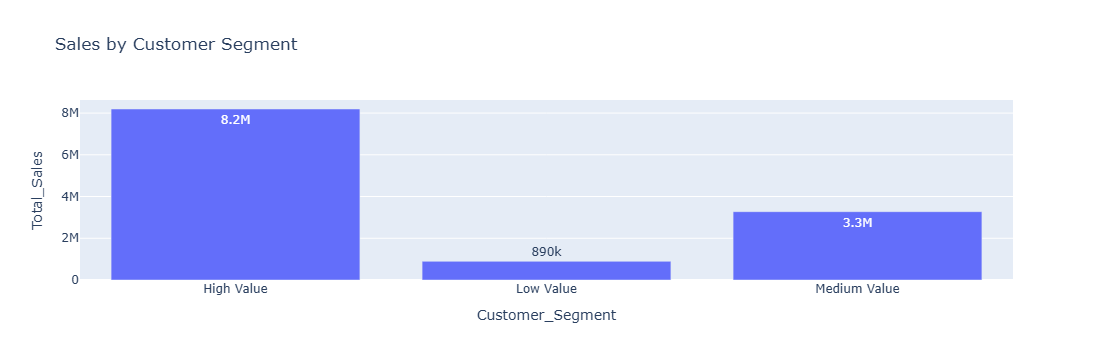

In [30]:
customer_spending = (
    df.groupby("Customer_ID")["Total_Sales"]
    .sum()
)

q1 = customer_spending.quantile(0.33)
q2 = customer_spending.quantile(0.66)

def segment_customer(value):
    if value <= q1:
        return "Low Value"
    elif value <= q2:
        return "Medium Value"
    else:
        return "High Value"

customer_segment = customer_spending.apply(segment_customer)

df["Customer_Segment"] = df["Customer_ID"].map(customer_segment)

segment_sales = (
    df.groupby("Customer_Segment")["Total_Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    segment_sales,
    x="Customer_Segment",
    y="Total_Sales",
    title="Sales by Customer Segment",
    text_auto=".2s"
)

fig.show()

fig.write_image("visualizations/customer_segment_sales.png")

In [31]:
import os

print(os.listdir("visualizations"))

['correlation_heatmap.png', 'customer_segment_sales.png', 'price_boxplot.png', 'product_performance.png', 'quantity_vs_sales.png', 'regional_sales.png', 'sales_trend.png', 'sales_violin.png']


In [3]:
readme = """# Interactive Sales Dashboard

## Project Overview
This project presents an interactive sales dashboard developed using Python, Pandas, Seaborn, Matplotlib, and Plotly.

## Objectives
- Analyze sales trends
- Compare product performance
- Analyze regional sales
- Understand customer segments
- Provide interactive Product and Region filters

## Technologies Used
- Python
- Pandas
- NumPy
- Plotly
- Seaborn
- Matplotlib
- Jupyter Notebook
- ipywidgets

## Visualizations
1. Daily Sales Trend
2. Sales by Product
3. Regional Sales Distribution
4. Quantity vs Total Sales
5. Price Distribution by Product
6. Sales Distribution by Region
7. Correlation Heatmap
8. Sales by Customer Segment

## Interactive Features
The dashboard provides Product and Region dropdown filters. Changing the filters updates the dashboard results.

## Key Insights
- Product performance can be compared using total sales.
- Regional analysis shows the contribution of different regions.
- Customers are segmented into Low Value, Medium Value, and High Value groups based on spending.
- Sales trends help identify changes in performance over time.

## Recommendations
- Focus on high-performing products.
- Monitor lower-performing regions.
- Develop strategies for different customer segments.
- Use sales trends for better planning.

## Project Files
- dashboard.ipynb
- dashboard.py
- sales_data.csv
- visualizations/
- requirements.txt

## How to Run
Install the required libraries using:

pip install -r requirements.txt

Then run dashboard.py using:

python dashboard.py
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme)

print("README.md created successfully!")

README.md created successfully!
